In [1]:
import numpy as np
import netket as nk

from netket.graph.common_lattices import Chain
from netket.operator.fermion import destroy as c
from netket.operator.fermion import create as cdag
from netket.operator.fermion import number as nc

print('NetKet version:', nk.__version__)

C:\Users\10783\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: With many Markov Chains (e.g GPUs), n_discard_per_chain>5 is often inefficient.

NetKet version: 3.21.1.dev13+gbf43effcb


In [12]:
import jax
import jax.numpy as jnp
import flax.linen as nn
import netket as nk
from flax.core import freeze, unfreeze

# ======================================================================
# 阶段一：Slater 决定式 (寻找最优的单粒子金属导带轨道)
# ======================================================================
class SlaterExpm(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    n_sites: int
    n_up: int
    n_down: int

    @nn.compact
    def __call__(self, n):
        dtype = jnp.float64
        x = n.astype(dtype)
        
        # 1. 声明底层生成元 kappa_vec，完全无冗余
        n_kappa = self.n_sites * (self.n_sites - 1) // 2
        # 【极其重要】：名字必须叫 'kappa_vec'，阶段二将根据这个名字继承参数
        kappa_vec = self.param('kappa_vec', nn.initializers.normal(stddev=0.01), (n_kappa,), dtype)
        
        # 2. 构造严格反对称矩阵
        tril_rows, tril_cols = jnp.tril_indices(self.n_sites, k=-1)
        kappa_zeros = jnp.zeros((self.n_sites, self.n_sites), dtype=dtype)
        kappa = kappa_zeros.at[tril_rows, tril_cols].set(kappa_vec)
        kappa = kappa.at[tril_cols, tril_rows].set(-kappa_vec) 
        
        # 3. 生成正交轨道矩阵 U
        U = jax.scipy.linalg.expm(kappa)
        
        # 4. 截取前 n_up 列作为占据轨道 (假设 n_up == n_down，纯 Singlet Slater)
        Phi_occ = U[:, :self.n_up]
        
        up_occ = x[..., :self.n_sites]
        down_occ = x[..., self.n_sites:]
        
        def get_occupied_indices(occ_array, num_particles):
            return jnp.argsort(-occ_array, axis=-1)[..., :num_particles]
            
        idx_up = get_occupied_indices(up_occ, self.n_up)
        idx_down = get_occupied_indices(down_occ, self.n_down)
        
        def extract_slater(idx):
            return Phi_occ[idx, :]
            
        sub_Phi_up = jax.vmap(extract_slater)(idx_up) if x.ndim > 1 else extract_slater(idx_up)
        sub_Phi_down = jax.vmap(extract_slater)(idx_down) if x.ndim > 1 else extract_slater(idx_down)
        
        # 5. Slater 态是上下自旋行列式的乘积
        sign_u, log_det_u = jnp.linalg.slogdet(sub_Phi_up)
        sign_d, log_det_d = jnp.linalg.slogdet(sub_Phi_down)
        
        log_amp = log_det_u + log_det_d
        log_sign = jnp.log((sign_u * sign_d).astype(jnp.complex128))
        return log_amp + log_sign

# ======================================================================
# 阶段二 & 三：纯 Singlet AGP + SIAM 杂质惩罚 Jastrow
# ======================================================================
class AGPSIAMJastrow(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    n_sites: int
    n_up: int
    n_down: int

    @nn.compact
    def __call__(self, n):
        dtype = jnp.float64
        x = n.astype(dtype)
        
        # 1. 声明相同的 kappa_vec (将被第一阶段的值覆盖)
        n_kappa = self.n_sites * (self.n_sites - 1) // 2
        kappa_vec = self.param('kappa_vec', nn.initializers.normal(stddev=0.01), (n_kappa,), dtype)
        
        # 2. 激活配对本征值 Lambda 
        # 【精妙之处】：初始化时前 n_up 个设为 1，其余为 0。
        # 结合继承过来的 kappa，此时的 AGP 态在数学上 $100\%$ 等价于上一步的 Slater 态！
        def init_fermi_sea(key, shape, dtype):
            base = jnp.zeros(shape, dtype=dtype)
            return base.at[:self.n_up].set(1.0)
            
        lambdas = self.param('pairing_eigenvalues', init_fermi_sea, (self.n_sites,), dtype)
        
        # 3. 构造配对矩阵 F
        tril_rows, tril_cols = jnp.tril_indices(self.n_sites, k=-1)
        kappa_zeros = jnp.zeros((self.n_sites, self.n_sites), dtype=dtype)
        kappa = kappa_zeros.at[tril_rows, tril_cols].set(kappa_vec)
        kappa = kappa.at[tril_cols, tril_rows].set(-kappa_vec) 
        
        U = jax.scipy.linalg.expm(kappa)
        F_matrix = jnp.dot(U * lambdas, U.T)
        
        # 4. 计算 AGP 行列式
        up_occ = x[..., :self.n_sites]
        down_occ = x[..., self.n_sites:]
        
        def get_occupied_indices(occ_array, num_particles):
            return jnp.argsort(-occ_array, axis=-1)[..., :num_particles]
            
        idx_up = get_occupied_indices(up_occ, self.n_up)
        idx_down = get_occupied_indices(down_occ, self.n_down)
        
        def extract_submatrix(idx_u, idx_d):
            return F_matrix[idx_u[:, None], idx_d]
            
        sub_F = jax.vmap(extract_submatrix)(idx_up, idx_down) if x.ndim > 1 else extract_submatrix(idx_up, idx_down)
            
        sign, log_det = jnp.linalg.slogdet(sub_F)
        log_agp = log_det + jnp.log(sign.astype(jnp.complex128))
        
        # ==================================================================
        # 5. 局域 Jastrow 惩罚：精准打击杂质双占 (Impurity at index 0)
        # ==================================================================
        # 初始化为一个较大的正数 (如 5.0)，第一时间掐断双占构型的高能冲击波
        g = self.param('impurity_penalty', nn.initializers.constant(5.0), ())
        
        n_imp_up = n[..., 0]                 # 杂质的上自旋占据
        n_imp_down = n[..., self.n_sites]    # 杂质的下自旋占据
        is_double_occupied = n_imp_up * n_imp_down
        
        # 对数域衰减
        log_jastrow = -g * is_double_occupied.astype(dtype)
        
        return log_agp + log_jastrow

chain nodes = 11 , chain edges = 10
n_orbitals = 12
fixed particles (N_up, N_dn) = (6, 6)


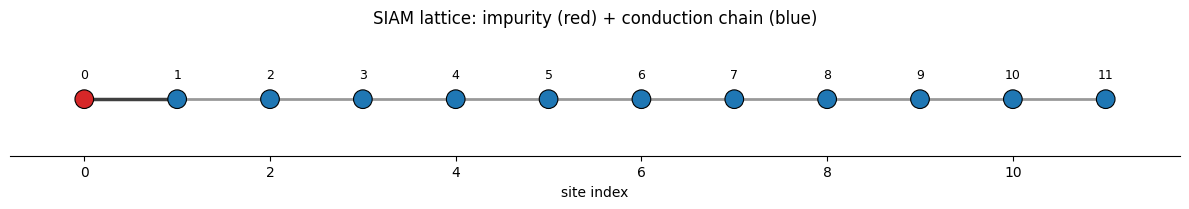

In [2]:
L = 11  # 导带链长度（不含杂质）
chain = Chain(L, pbc=False)
N = chain.n_nodes   # 格点数量，后续会被应用为神经网络的优化参数数量

impurity_site = 0
conduction_offset = 1  # 导带链局部索引 i -> 全局站点 i+1
n_orbitals = L + 1  # 1 个杂质轨道 + L 个导带轨道

if n_orbitals % 2 != 0:
    raise ValueError("n_orbitals 必须为偶数，才能设置 N_up = N_dn = n_orbitals/2")

N_up = n_orbitals // 2
N_dn = n_orbitals // 2

# 在这里直接限制 Hilbert 空间粒子数
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals, s=1 / 2, n_fermions_per_spin=(N_up, N_dn)
 )

print('chain nodes =', chain.n_nodes, ', chain edges =', chain.n_edges)
print('n_orbitals =', n_orbitals)
print('fixed particles (N_up, N_dn) =', (N_up, N_dn))


U = 4.0
V = 0.15
ti = np.ones(L - 1)  # t_i: 导带链上相邻站点之间的 hopping, 长度 L-1

H = 0.0

# 杂质上的库仑相互作用: U (n_d↑ - 1/2)(n_d↓ - 1/2)
n_d_up = nc(hi, impurity_site, sz=+1)
n_d_dn = nc(hi, impurity_site, sz=-1)
H += U * (n_d_up - 0.5) @ (n_d_dn - 0.5)

h_pin = 0.00
H -= h_pin * 0.5 * (n_d_up - n_d_dn)
# 杂质-导带首站点混成: V Σσ (d†σ c0σ + c0†σ dσ)
c0_site = conduction_offset
for sz in (+1, -1):
    H += V * (cdag(hi, impurity_site, sz=sz) @ c(hi, c0_site, sz=sz))
    H += V * (cdag(hi, c0_site, sz=sz) @ c(hi, impurity_site, sz=sz))

# 导带链 hopping: Σσ Σ_i t_i (c†_{iσ} c_{i-1,σ} + h.c.)
# 使用 Chain(L) 的边来确定一维最近邻，局部索引 (0..L-1) 需要偏移到全局站点 (1..L)。
for i_local, j_local in chain.edges():
    left_local, right_local = sorted((i_local, j_local))
    t_bond = ti[left_local]

    left_site = left_local + conduction_offset
    right_site = right_local + conduction_offset

    for sz in (+1, -1):
        H += t_bond * (cdag(hi, right_site, sz=sz) @ c(hi, left_site, sz=sz))
        H += t_bond * (cdag(hi, left_site, sz=sz) @ c(hi, right_site, sz=sz))

H
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(12, 2.2))

# 导带内部边（将 chain 的局部索引映射到全局站点 1..L）
for i_local, j_local in chain.edges():
    ax.plot(
        [i_local + conduction_offset, j_local + conduction_offset],
        [0, 0],
        color="0.6",
        lw=2,
        zorder=1,
    )

# 杂质-导带首站点混成边
ax.plot([impurity_site, c0_site], [0, 0], color="0.25", lw=2.5, zorder=2)

# 节点着色：杂质红色，其它导带蓝色
x = np.arange(n_orbitals)
y = np.zeros(n_orbitals)
node_colors = ["tab:red"] + ["tab:blue"] * L
ax.scatter(x, y, c=node_colors, s=180, edgecolors="black", linewidths=0.8, zorder=3)

for site in range(n_orbitals):
    ax.text(site, 0.08, str(site), ha="center", va="bottom", fontsize=9)

ax.set_yticks([])
ax.set_xlabel("site index")
ax.set_title("SIAM lattice: impurity (red) + conduction chain (blue)")
ax.set_xlim(-0.8, n_orbitals - 0.2)
ax.set_ylim(-0.25, 0.3)
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
plt.tight_layout()
plt.show()

In [14]:
import jax
import jax.numpy as jnp
import flax.linen as nn
import netket as nk
from functools import partial

# ========= Reproducibility seeds =========
SEED_MODEL_SLATER = 11
SEED_SAMPLER_SLATER = 101
SEED_MODEL_NJ = 22
SEED_SAMPLER_NJ = 202
SEED_MODEL_BF = 33
SEED_SAMPLER_BF = 303

# 给采样器构造“空间轨道图”：杂质-首导带 + 导带链最近邻
sampler_edges = [(impurity_site, c0_site)]
sampler_edges += [
    (min(i, j) + conduction_offset, max(i, j) + conduction_offset)
    for (i, j) in chain.edges()
 ]
graph_sampler = nk.graph.Graph(edges=sampler_edges, n_nodes=n_orbitals)

# ==============================================================================
# 体系太大，已彻底移除 ED (Exact Diagonalization) 精确求解部分
# ==============================================================================
E_gs = None 

print("reference E_gs = Not Available (System too large for ED)")
print("sampler graph nodes/edges =", graph_sampler.n_nodes, graph_sampler.n_edges)
print(
    "seeds:",
    (SEED_MODEL_SLATER, SEED_SAMPLER_SLATER, SEED_MODEL_NJ, SEED_SAMPLER_NJ, SEED_MODEL_BF, SEED_SAMPLER_BF),
)

reference E_gs = Not Available (System too large for ED)
sampler graph nodes/edges = 12 11
seeds: (11, 101, 22, 202, 33, 303)


In [22]:
import optax
import netket as nk
import jax.numpy as jnp

print("=" * 70)
print(">>> [升级版] AGP + SIAM 专属优化器：动态 SR 与防爆 Adam")
print("=" * 70)

# ==============================================================================
# 3. 采样器与变分态 (VState)
# ==============================================================================
# 【修正 1】：删除了报错的 nk.graph.Star(N) 
# 我们直接沿用你前面代码块里极其标准、完美的 graph_sampler！
sa = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler)

# 【修正 2】：参数名称必须对齐。
# 在你的第一个块中，N = 11 (仅导带), n_orbitals = 12 (总格点)。
# Pfaffian 矩阵必须覆盖所有格点，所以 n_sites 必须传入 n_orbitals！
model_agp = AGPSIAMJastrow(hilbert=hi, n_sites=n_orbitals, n_up=N_up, n_down=N_dn)

vstate_agp = nk.vqs.MCState(
    sampler=sa,
    model=model_agp,
    n_samples=2**13,         
    n_discard_per_chain=32,
    seed=SEED_MODEL_BF,           # 带上你定义的随机种子，保证可复现
    sampler_seed=SEED_SAMPLER_BF
)

print(f"变分态初始化完成！总参数量: {vstate_agp.n_parameters}")
print("=" * 70)

# ==============================================================================
# 4. 外层优化器 (适应 300 步压缩版)
# ==============================================================================
lr_schedule_agp = optax.cosine_decay_schedule(
    init_value=0.002,  
    decay_steps=300,   
    alpha=0.01  
)

op_agp = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(
        learning_rate=lr_schedule_agp,
        b1=0.8,            
        b2=0.999,          
        eps=1e-8
    )
)

# ==============================================================================
# 5. 内层预条件器：自然梯度 (SR) 调度
# ==============================================================================
sr_shift_schedule = optax.linear_schedule(
    init_value=0.05,       
    end_value=0.001,       
    transition_steps=200   
)

sr_agp = nk.optimizer.SR(
    diag_shift=sr_shift_schedule,
    solver=nk.optimizer.solver.pinv,  
    holomorphic=False, 
    qgt=nk.optimizer.qgt.QGTJacobianDense
)

# ==============================================================================
# 6. 驱动器构建与运行
# ==============================================================================
gs_agp = nk.VMC(
    hamiltonian=H,       
    optimizer=op_agp, 
    preconditioner=sr_agp,
    variational_state=vstate_agp
)

agp_log = nk.logging.RuntimeLog()
print("开始运行 SIAM 的 AGP 强关联优化 (已开启防爆保护与动态 SR)...")

# 运行 500 步
gs_agp.run(n_iter=500, out=agp_log)

print("-" * 70)
E_agp = vstate_agp.expect(H)
print(f"AGP+Jastrow optimized energy: {E_agp}")
print("=" * 70)

>>> [升级版] AGP + SIAM 专属优化器：动态 SR 与防爆 Adam
变分态初始化完成！总参数量: 79
开始运行 SIAM 的 AGP 强关联优化 (已开启防爆保护与动态 SR)...


100%|██████████| 500/500 [06:30<00:00,  1.28it/s, Energy=-11.870-0.000j ± 0.049 [σ²=3.0e+00, R̂=1.034]]


----------------------------------------------------------------------
AGP+Jastrow optimized energy: -11.973-0.000j ± 0.042 [σ²=2.6e+00, R̂=1.012]


In [18]:
class LogSlaterDeterminant(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions

    @nn.compact
    def __call__(self, n):
        # 直接复用 NetKet 内建 Slater2nd（限制在固定粒子数子空间）
        return nk.models.Slater2nd(
            self.hilbert, generalized=False, restricted=True, param_dtype=float
        )(n)

In [ ]:
import optax
import netket as nk
import jax.numpy as jnp

print("=" * 70)
print(">>> [升级版] AGP + SIAM 专属优化器：动态 SR 与防爆 Adam")
print("=" * 70)

# ==============================================================================
# 3. 采样器与变分态 (VState)
# ==============================================================================
# 【修正 1】：删除了报错的 nk.graph.Star(N) 
# 我们直接沿用你前面代码块里极其标准、完美的 graph_sampler！
sa = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler)

# 【修正 2】：参数名称必须对齐。
# 在你的第一个块中，N = 11 (仅导带), n_orbitals = 12 (总格点)。
# Pfaffian 矩阵必须覆盖所有格点，所以 n_sites 必须传入 n_orbitals！
model_agp = LogSlaterDeterminant(hilbert=hi)

vstate_agp = nk.vqs.MCState(
    sampler=sa,
    model=model_agp,
    n_samples=2**13,         
    n_discard_per_chain=32,
    seed=SEED_MODEL_BF,           # 带上你定义的随机种子，保证可复现
    sampler_seed=SEED_SAMPLER_BF
)

print(f"变分态初始化完成！总参数量: {vstate_agp.n_parameters}")
print("=" * 70)

# ==============================================================================
# 4. 外层优化器 (适应 300 步压缩版)
# ==============================================================================
lr_schedule_agp = optax.cosine_decay_schedule(
    init_value=0.002,  
    decay_steps=300,   
    alpha=0.01  
)

op_agp = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(
        learning_rate=lr_schedule_agp,
        b1=0.8,            
        b2=0.999,          
        eps=1e-8
    )
)

# ==============================================================================
# 5. 内层预条件器：自然梯度 (SR) 调度
# ==============================================================================
sr_shift_schedule = optax.linear_schedule(
    init_value=0.05,       
    end_value=0.001,       
    transition_steps=200   
)

sr_agp = nk.optimizer.SR(
    diag_shift=sr_shift_schedule,
    solver=nk.optimizer.solver.pinv,  
    holomorphic=False, 
    qgt=nk.optimizer.qgt.QGTJacobianDense
)

# ==============================================================================
# 6. 驱动器构建与运行
# ==============================================================================
gs_agp = nk.VMC(
    hamiltonian=H,       
    optimizer=op_agp, 
    preconditioner=sr_agp,
    variational_state=vstate_agp
)

agp_log = nk.logging.RuntimeLog()
print("开始运行 SIAM 的 RHF 强关联优化 (已开启防爆保护与动态 SR)...")

# 运行 500 步
gs_agp.run(n_iter=500, out=agp_log)

print("-" * 70)
E_agp = vstate_agp.expect(H)
print(f"RHF+Jastrow optimized energy: {E_agp}")
print("=" * 70)

>>> [升级版] AGP + SIAM 专属优化器：动态 SR 与防爆 Adam
变分态初始化完成！总参数量: 72
开始运行 SIAM 的 AGP 强关联优化 (已开启防爆保护与动态 SR)...


100%|██████████| 500/500 [05:43<00:00,  1.46it/s, Energy=-11.920+0.000j ± 0.033 [σ²=2.7e+00, R̂=1.014]]


----------------------------------------------------------------------
AGP+Jastrow optimized energy: -11.928-0.000j ± 0.029 [σ²=2.4e+00, R̂=1.005]


In [20]:
class LogSlaterDeterminant(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions

    @nn.compact
    def __call__(self, n):
        # 直接复用 NetKet 内建 Slater2nd（限制在固定粒子数子空间）
        return nk.models.Slater2nd(
            self.hilbert, generalized=False, restricted=False, param_dtype=float
        )(n)

In [21]:
import optax
import netket as nk
import jax.numpy as jnp

print("=" * 70)
print(">>> [升级版] AGP + SIAM 专属优化器：动态 SR 与防爆 Adam")
print("=" * 70)

# ==============================================================================
# 3. 采样器与变分态 (VState)
# ==============================================================================
# 【修正 1】：删除了报错的 nk.graph.Star(N) 
# 我们直接沿用你前面代码块里极其标准、完美的 graph_sampler！
sa = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler)

# 【修正 2】：参数名称必须对齐。
# 在你的第一个块中，N = 11 (仅导带), n_orbitals = 12 (总格点)。
# Pfaffian 矩阵必须覆盖所有格点，所以 n_sites 必须传入 n_orbitals！
model_agp = LogSlaterDeterminant(hilbert=hi)

vstate_agp = nk.vqs.MCState(
    sampler=sa,
    model=model_agp,
    n_samples=2**13,         
    n_discard_per_chain=32,
    seed=SEED_MODEL_BF,           # 带上你定义的随机种子，保证可复现
    sampler_seed=SEED_SAMPLER_BF
)

print(f"变分态初始化完成！总参数量: {vstate_agp.n_parameters}")
print("=" * 70)

# ==============================================================================
# 4. 外层优化器 (适应 300 步压缩版)
# ==============================================================================
lr_schedule_agp = optax.cosine_decay_schedule(
    init_value=0.002,  
    decay_steps=300,   
    alpha=0.01  
)

op_agp = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(
        learning_rate=lr_schedule_agp,
        b1=0.8,            
        b2=0.999,          
        eps=1e-8
    )
)

# ==============================================================================
# 5. 内层预条件器：自然梯度 (SR) 调度
# ==============================================================================
sr_shift_schedule = optax.linear_schedule(
    init_value=0.05,       
    end_value=0.001,       
    transition_steps=200   
)

sr_agp = nk.optimizer.SR(
    diag_shift=sr_shift_schedule,
    solver=nk.optimizer.solver.pinv,  
    holomorphic=False, 
    qgt=nk.optimizer.qgt.QGTJacobianDense
)

# ==============================================================================
# 6. 驱动器构建与运行
# ==============================================================================
gs_agp = nk.VMC(
    hamiltonian=H,       
    optimizer=op_agp, 
    preconditioner=sr_agp,
    variational_state=vstate_agp
)

agp_log = nk.logging.RuntimeLog()
print("开始运行 SIAM 的 AGP 强关联优化 (已开启防爆保护与动态 SR)...")

# 运行 500 步
gs_agp.run(n_iter=500, out=agp_log)

print("-" * 70)
E_agp = vstate_agp.expect(H)
print(f"AGP+Jastrow optimized energy: {E_agp}")
print("=" * 70)

>>> [升级版] AGP + SIAM 专属优化器：动态 SR 与防爆 Adam
变分态初始化完成！总参数量: 144
开始运行 SIAM 的 AGP 强关联优化 (已开启防爆保护与动态 SR)...


100%|██████████| 500/500 [05:35<00:00,  1.49it/s, Energy=-13.439+0.000j ± 0.017 [σ²=1.3e+00, R̂=1.004]]


----------------------------------------------------------------------
AGP+Jastrow optimized energy: -13.404+0.000j ± 0.017 [σ²=1.4e+00, R̂=1.003]


In [3]:
from math import comb
from scipy.sparse.linalg import eigsh
from netket.experimental.operator import ParticleNumberAndSpinConservingFermioperator2nd

# 直接复用第 3 段已构造好的 H（其 Hilbert 空间已固定粒子数）
N_up_ed, N_dn_ed = N_up, N_dn
sector_dim = comb(n_orbitals, N_up_ed) * comb(n_orbitals, N_dn_ed)
max_dim_for_sparse_ed = 2000000  # 经验阈值，可按机器内存调整

print("ED sector (N_up, N_dn) =", (N_up_ed, N_dn_ed))
print("Estimated Hilbert dimension =", sector_dim)

if sector_dim > max_dim_for_sparse_ed:
    print(
        "[Skip ED] 该扇区维度过大，不执行 to_sparse()/eigsh 以避免内存溢出。"
    )
    print("建议: 减小粒子数（如 1,1 或 2,2）后再做严格对角化。")
else:
    H_ed = ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(H)
    sp_h = H_ed.to_sparse()
    eig_vals, eig_vecs = eigsh(sp_h, k=4, which="SA")
    eig_vals = np.sort(np.real(eig_vals))

    print("Hilbert dimension in this sector =", sp_h.shape[0])
    print("Exact ground-state energy E0 =", eig_vals[0])
    print("Lowest 4 eigenvalues =", eig_vals)

ED sector (N_up, N_dn) = (6, 6)
Estimated Hilbert dimension = 853776
Hilbert dimension in this sector = 853776
Exact ground-state energy E0 = -14.205504941705273
Lowest 4 eigenvalues = [-14.20550494 -14.19792567 -13.68833242 -13.68813464]


>>> [物理测量] 全空间分块：带自旋标签的自然轨道占据数
正在分别构建 Spin-Down 和 Spin-Up 的单体密度矩阵...
  -> 计算 Down (↓) 扇区...
  -> 计算 Up (↑) 扇区...
----------------------------------------------------------------------
全空间自然轨道占据数 (严格降序, 带有自旋标签):
  全局轨道  0 [↓]: 1.000000
  全局轨道  1 [↑]: 1.000000
  全局轨道  2 [↓]: 1.000000
  全局轨道  3 [↑]: 1.000000
  全局轨道  4 [↓]: 1.000000
  全局轨道  5 [↑]: 1.000000
  ... (省略中间部分) ...
  全局轨道 18 [↑]: 0.000000
  全局轨道 19 [↓]: 0.000000
  全局轨道 20 [↑]: 0.000000
  全局轨道 21 [↓]: 0.000000
  全局轨道 22 [↑]: 0.000000
  全局轨道 23 [↓]: -0.000000


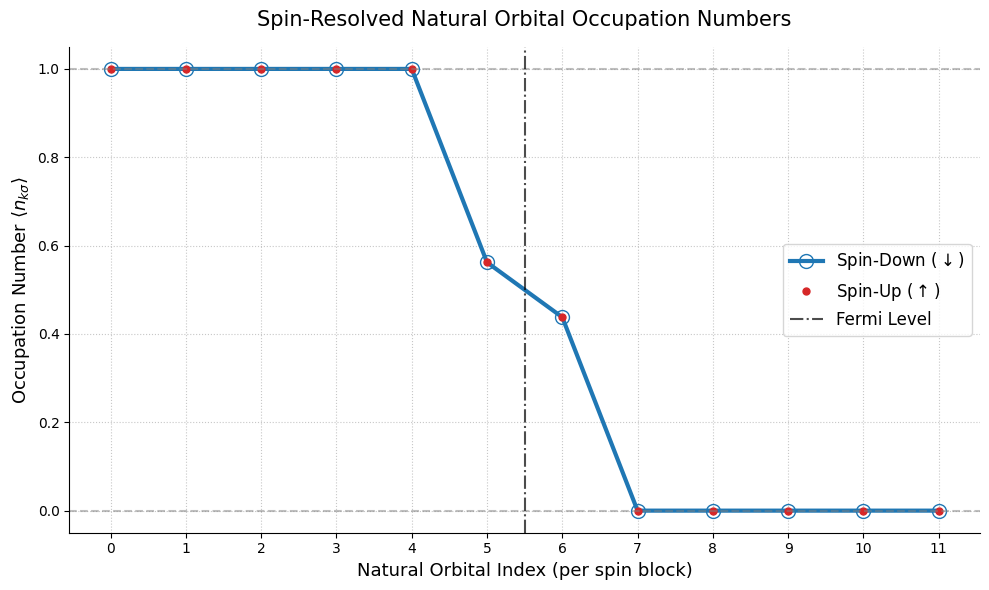

In [4]:
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print(">>> [物理测量] 全空间分块：带自旋标签的自然轨道占据数")
print("=" * 70)

if 'eig_vecs' not in locals():
    print("[错误] 未找到精确对角化结果。")
else:
    psi0 = np.asarray(eig_vecs[:, 0])
    states = np.asarray(hi.all_states())
    
    # 初始化两个自旋子块的密度矩阵
    rho_dn = np.zeros((n_orbitals, n_orbitals), dtype=complex)
    rho_up = np.zeros((n_orbitals, n_orbitals), dtype=complex)
    
    print(f"正在分别构建 Spin-Down 和 Spin-Up 的单体密度矩阵...")
    
    # 遍历两个自旋扇区
    # Spin-Down 的物理格点映射到数组的 [0, n_orbitals - 1]
    # Spin-Up   的物理格点映射到数组的 [n_orbitals, 2*n_orbitals - 1]
    for spin_name, offset, rho in [('Down (↓)', 0, rho_dn), ('Up (↑)', n_orbitals, rho_up)]:
        print(f"  -> 计算 {spin_name} 扇区...")
        for i in range(n_orbitals):
            idx_i = i + offset
            for j in range(n_orbitals):
                idx_j = j + offset
                
                if i == j:
                    mask = states[:, idx_i] == 1
                    rho[i, i] = np.sum(np.abs(psi0[mask])**2)
                else:
                    mask = (states[:, idx_j] == 1) & (states[:, idx_i] == 0)
                    valid_indices = np.where(mask)[0]
                    
                    if len(valid_indices) == 0:
                        continue
                        
                    valid_states = states[valid_indices]
                    target_states = valid_states.copy()
                    
                    target_states[:, idx_j] = 0
                    target_states[:, idx_i] = 1
                    
                    start, end = min(idx_i, idx_j) + 1, max(idx_i, idx_j)
                    n_between = np.sum(valid_states[:, start:end], axis=1)
                    signs = (-1.0) ** n_between
                    
                    target_indices = hi.states_to_numbers(target_states)
                    rho[i, j] = np.sum(np.conj(psi0[target_indices]) * signs * psi0[valid_indices])
        
        # 厄米化
        rho[:, :] = 0.5 * (rho + rho.conj().T)

    # ==========================================================================
    # 对角化两个子块并打上自旋标签
    # ==========================================================================
    occ_dn, _ = np.linalg.eigh(rho_dn)
    occ_up, _ = np.linalg.eigh(rho_up)
    
    # 组合为带有标签的列表: [(占据数, '↓'), (占据数, '↑'), ...]
    all_occs = [(np.real(val), '↓') for val in occ_dn] + [(np.real(val), '↑') for val in occ_up]
    
    # 按占据数从大到小严格排序
    all_occs.sort(key=lambda x: x[0], reverse=True)
    
    print("-" * 70)
    print("全空间自然轨道占据数 (严格降序, 带有自旋标签):")
    # 只打印前几个和后几个展示简并性
    for k, (val, spin) in enumerate(all_occs):
        if k < 6 or k > 2 * n_orbitals - 7:
            print(f"  全局轨道 {k:2d} [{spin}]: {val:.6f}")
        elif k == 6:
            print("  ... (省略中间部分) ...")

    # ==========================================================================
    # 绘图部分：双自旋同台对比
    # ==========================================================================
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # 提取排序好的 up 和 dn 的占据数用于画图
    occ_dn_sorted = np.sort(np.real(occ_dn))[::-1]
    occ_up_sorted = np.sort(np.real(occ_up))[::-1]
    indices = np.arange(n_orbitals)
    
    # 【画图技巧】：为了证明它们完全重合，我们用大空心圆画 Down，用小实心点画 Up
    ax.plot(indices, occ_dn_sorted, marker='o', markersize=10, linestyle='-', linewidth=3, 
            color='tab:blue', fillstyle='none', label="Spin-Down ($\downarrow$)")
    
    ax.plot(indices, occ_up_sorted, marker='o', markersize=5, linestyle='', 
            color='tab:red', label="Spin-Up ($\\uparrow$)")
    
    ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
    ax.axhline(0.0, color='gray', linestyle='--', alpha=0.5)
    
    ax.axvline(N_up - 0.5, color='black', linestyle='-.', alpha=0.7, label="Fermi Level")
    
    ax.set_title("Spin-Resolved Natural Orbital Occupation Numbers", fontsize=15, pad=15)
    ax.set_xlabel("Natural Orbital Index (per spin block)", fontsize=13)
    ax.set_ylabel("Occupation Number $\\langle n_{k\\sigma} \\rangle$", fontsize=13)
    ax.set_xticks(indices)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(fontsize=12)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    print("=" * 70)

In [5]:
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print(">>> [物理测量] 自然轨道的实空间投影 (Kondo Cloud Visualization)")
print("=" * 70)

# 1. 提取自然轨道矩阵并计算实空间概率密度
# nat_orbs 形状为 (n_orbitals, n_orbitals)，第 k 列是第 k 个自然轨道
# 计算 |phi_k(x)|^2，即第 k 个轨道在各个格点上的占据概率
prob_density = np.abs(nat_orbs)**2 

# 2. 绘制可视化图表
fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [1.2, 1]})

# ==============================================================================
# 左图：所有自然轨道的空间分布热力图
# ==============================================================================
ax1 = axes[0]
# 转置 prob_density 使得 Y 轴是轨道索引，X 轴是实空间格点
im = ax1.imshow(prob_density.T, cmap='Blues', aspect='auto')

# 标出费米面位置
ax1.axhline(N_up - 0.5, color='tab:red', linestyle='--', linewidth=2, label="Fermi Level")

ax1.set_xticks(np.arange(n_orbitals))
# 突出显示杂质格点 (Imp) 和导带格点 (1..L)
ax1.set_xticklabels(['Imp (0)'] + [str(i) for i in range(1, n_orbitals)])
ax1.set_yticks(np.arange(n_orbitals))
ax1.set_ylabel("Natural Orbital Index ($k$)")
ax1.set_xlabel("Real Space Site Index ($x$)")
ax1.set_title("Spatial Probability Density $|\phi_k(x)|^2$ of All NOs", pad=15)
ax1.legend(loc='upper right')
plt.colorbar(im, ax=ax1, label="Probability Density", pad=0.02)

# ==============================================================================
# 右图：费米面附近“活性轨道”的实空间截面剖析
# ==============================================================================
ax2 = axes[1]
# 提取费米面正下方和正上方的两个轨道 (在这个例子中是 k=5 和 k=6)
k_below = N_up - 1
k_above = N_up

# 画出这两个轨道在实空间的波函数概率分布
ax2.plot(np.arange(n_orbitals), prob_density[:, k_below], marker='o', color='tab:orange', 
         linewidth=2, label=f'NO {k_below} (Occ={occ_nums[k_below]:.3f})')
ax2.plot(np.arange(n_orbitals), prob_density[:, k_above], marker='s', color='tab:green', 
         linewidth=2, label=f'NO {k_above} (Occ={occ_nums[k_above]:.3f})')

ax2.set_xticks(np.arange(n_orbitals))
ax2.set_xticklabels(['Imp'] + [str(i) for i in range(1, n_orbitals)])
ax2.set_title("Active Orbitals near Fermi Level", pad=15)
ax2.set_xlabel("Real Space Site Index ($x$)")
ax2.set_ylabel("Probability Density $|\phi_k(x)|^2$")
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend()

# 美化边框
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()
print("=" * 70)

>>> [物理测量] 自然轨道的实空间投影 (Kondo Cloud Visualization)


NameError: name 'nat_orbs' is not defined